In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# Seed zapewnia identyczne dane u każdego studenta
np.random.seed(42)
n = 200
dzialy = np.random.choice(['IT', 'Sprzedaz', 'HR', 'Marketing', 'Finanse'], n,
p=[0.30, 0.25, 0.15, 0.20, 0.10])
staz = np.random.gamma(shape=3, scale=2, size=n).clip(0.5, 20).round(1)
baza = {'IT': 9000, 'Sprzedaz': 7000, 'HR': 6500, 'Marketing': 7500, 'Finanse':
8500}
wynagrodzenie = np.array([
baza[d] + staz[i] * 300 + np.random.normal(0, 1200)
for i, d in enumerate(dzialy)
]).clip(4000, 25000).round(-2)
# 5 celowo wstawionych outlierów (błędy danych / kontrakty specjalne)
wynagrodzenie[np.random.choice(n, 5, replace=False)] = np.random.choice(
[2000, 2500, 35000, 40000, 38000], 5, replace=False
)
df = pd.DataFrame({
'dzial': dzialy,
'staz_lat': staz,
'wynagrodzenie': wynagrodzenie,
'wiek': (25 + staz + np.random.normal(0, 3, n)).clip(22,
65).round().astype(int),
'ocena_roczna': np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.40,
0.35, 0.10])
})
print(f"Dataset HR: {df.shape[0]} pracowników, {df.shape[1]} kolumn")
print(df.head())
print("\nTypy kolumn:")
print(df.dtypes)

Dataset HR: 200 pracowników, 5 kolumn
       dzial  staz_lat  wynagrodzenie  wiek  ocena_roczna
0   Sprzedaz       3.4         9100.0    27             5
1    Finanse       6.1        12600.0    35             3
2  Marketing       6.3         7700.0    38             3
3         HR       3.3         8200.0    27             4
4         IT      14.0        12400.0    38             4

Typy kolumn:
dzial                str
staz_lat         float64
wynagrodzenie    float64
wiek               int64
ocena_roczna       int64
dtype: object


## Ćwiczenie 1: Statystyki opisowe na danych biznesowych (20 min)

#### 1a. Miary tendencji centralnej

In [2]:
placa = df['wynagrodzenie']
srednia = placa.mean()
mediana = placa.median()
dominanta = placa.mode()[0]
print("=== MIARY TENDENCJI CENTRALNEJ ===")
print(f"Średnia: {srednia:>10,.0f} PLN")
print(f"Mediana: {mediana:>10,.0f} PLN")
print(f"Dominanta: {dominanta:>10,.0f} PLN")
# Czy mediana < średnia? Co to mówi o rozkładzie?
# Tak, to oznacza rozkład prawostronnie asymetryczny (prawoskośny). 
# Niewielka liczba osób zarabia bardzo dużo, sztucznie zawyżając średnią, 
# przez co większość pracowników (ponad 50%) zarabia poniżej średniej krajowej/firmowej.

=== MIARY TENDENCJI CENTRALNEJ ===
Średnia:      9,940 PLN
Mediana:      9,450 PLN
Dominanta:      9,500 PLN


#### 1b. Miary rozproszenia

In [4]:
placa = df['wynagrodzenie']
odch_std = placa.std()
q1 = placa.quantile(0.25)
q3 = placa.quantile(0.75)
iqr = q3 - q1
rozstep = placa.max() - placa.min()

print("=== MIARY ROZPROSZENIA ===")
print(f"Odchylenie std: {odch_std:>10,.0f} PLN")
print(f"Q1 (P25): {q1:>10,.0f} PLN")
print(f"Q3 (P75): {q3:>10,.0f} PLN")
print(f"IQR: {iqr:>10,.0f} PLN")
print(f"Rozstęp: {rozstep:>10,.0f} PLN")
# Odpowiedz w komentarzu: dlaczego rozstęp jest tak duży?
# Rozstęp bazuje wyłącznie na wartościach skrajnych (Max - Min). 
# Jest tak duży, ponieważ w danych występują pojedyncze, bardzo wysokie zarobki 
# (wartości odstające, np. kadra zarządzająca), co sztucznie zwiększa tę miarę,

=== MIARY ROZPROSZENIA ===
Odchylenie std:      3,980 PLN
Q1 (P25):      8,200 PLN
Q3 (P75):     10,700 PLN
IQR:      2,500 PLN
Rozstęp:     38,000 PLN


#### 1c. Statystyki per dział

In [5]:
dzialy_stats = df.groupby('dzial', observed=True)['wynagrodzenie'].agg([
'mean', 'median', 'std'
]).round(0).sort_values('median', ascending=False)
dzialy_stats.columns = ['Średnia', 'Mediana', 'Std']
print("=== WYNAGRODZENIA PER DZIAŁ ===")
print(dzialy_stats)

=== WYNAGRODZENIA PER DZIAŁ ===
           Średnia  Mediana     Std
dzial                              
IT         11108.0  10600.0  4145.0
Finanse    10621.0  10400.0  1741.0
Marketing   9476.0   9100.0  4386.0
HR          8354.0   8400.0  1622.0
Sprzedaz    9282.0   8400.0  4428.0


#### 1d. Wizualizacja — histogram z miarami centralnymi

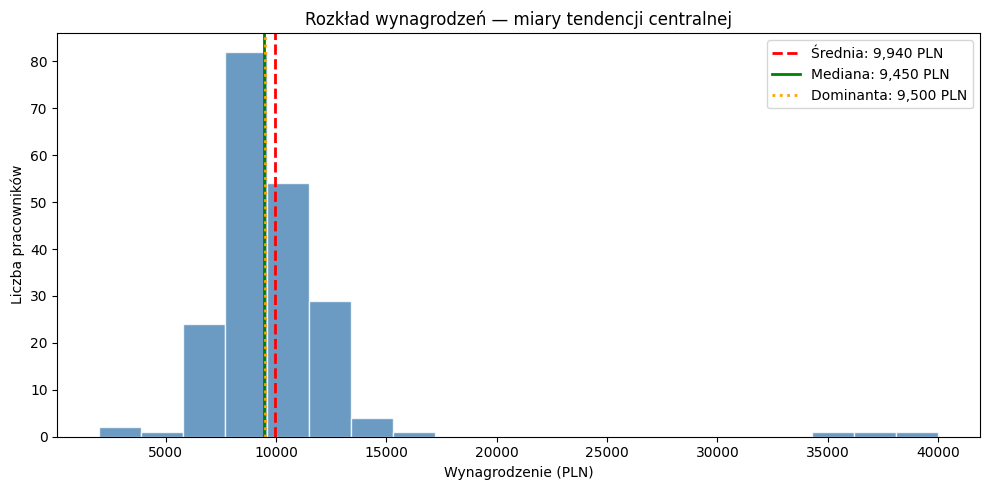

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

# Uzupełnij ___ wartościami:
ax.hist(placa, bins=20, color='steelblue', alpha=0.8, edgecolor='white')

ax.axvline(srednia, color='red', linestyle='--', lw=2, label=f'Średnia: {srednia:,.0f} PLN')
ax.axvline(mediana, color='green', linestyle='-', lw=2, label=f'Mediana: {mediana:,.0f} PLN')
ax.axvline(dominanta, color='orange', linestyle=':', lw=2, label=f'Dominanta: {dominanta:,.0f} PLN')

# Uwaga: dominanta i mediana mogą się prawie pokryć — to też informacja
ax.set_title('Rozkład wynagrodzeń — miary tendencji centralnej')
ax.set_xlabel('Wynagrodzenie (PLN)')
ax.set_ylabel('Liczba pracowników')
ax.legend()

plt.tight_layout()
plt.show()
plt.close()

## Ćwiczenie 2: Analiza korelacji (20 min)

#### 2a. Korelacja Pearsona: staż vs wynagrodzenie

In [11]:
from scipy import stats

nazwa_kolumny_staz = next((col for col in df.columns if 'sta' in col.lower()), None)

if nazwa_kolumny_staz is None:
    raise KeyError("Nie znaleziono kolumny odpowiadającej za staż! Sprawdź df.columns")

r, p_value = stats.pearsonr(df[nazwa_kolumny_staz], df['wynagrodzenie'])

print(f"Korelacja Pearsona ({nazwa_kolumny_staz}–wynagrodzenie):")
print(f"  r = {r:.4f}")
print(f"  p = {p_value:.4f}")
print(f"  Interpretacja: {'istotna' if p_value < 0.05 else 'nieistotna'} statystycznie")

Korelacja Pearsona (staz_lat–wynagrodzenie):
  r = 0.3198
  p = 0.0000
  Interpretacja: istotna statystycznie


#### 2b. Korelacja Spearmana — porównanie

In [12]:
rho, p_rho = stats.spearmanr(df[nazwa_kolumny_staz], df['wynagrodzenie'])

print(f"Korelacja Spearmana (staż–wynagrodzenie):")
print(f" rho = {rho:.4f}")
print(f" p = {p_rho:.4f}")
print(f"\nPorównanie: Pearson r={r:.3f} vs Spearman rho={rho:.3f}")
print(f"Różnica: {abs(rho - r):.3f} — {'duże' if abs(rho-r) > 0.1 else 'małe'} rozbieżności")

# Odpowiedz w komentarzu: dlaczego Spearman jest wyższy niż Pearson?
# Spearman jest wyższy, ponieważ bada monotoniczność relacji, a nie tylko liniowość. 
# W przeciwieństwie do Pearsona, Spearman operuje na rangach (pozycjach), dzięki czemu 
# jest odporny na wartości odstające (outliery) – czyli np. anomalnie wysokie zarobki kadry, 
# które drastycznie zaniżają standardowy współczynnik Pearsona.

Korelacja Spearmana (staż–wynagrodzenie):
 rho = 0.5219
 p = 0.0000

Porównanie: Pearson r=0.320 vs Spearman rho=0.522
Różnica: 0.202 — duże rozbieżności


#### 2c. Macierz korelacji — wszystkie zmienne

Macierz korelacji Pearsona:
               staz_lat  wynagrodzenie   wiek  ocena_roczna
staz_lat          1.000          0.320  0.756        -0.057
wynagrodzenie     0.320          1.000  0.219        -0.054
wiek              0.756          0.219  1.000        -0.081
ocena_roczna     -0.057         -0.054 -0.081         1.000


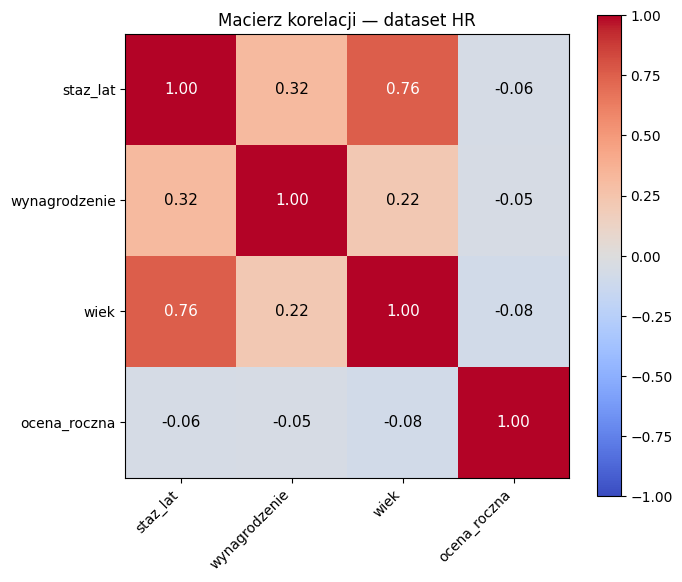

In [15]:
# Oblicz pełną macierz korelacji Pearsona
corr = df[['staz_lat', 'wynagrodzenie', 'wiek', 'ocena_roczna']].corr()
print("Macierz korelacji Pearsona:")
print(corr.round(3))
# Wizualizacja — heatmapa (matplotlib już zaimportowany w Setupie)
fig, ax = plt.subplots(figsize=(7, 6))
# Rysuj heatmapę ręcznie (bez seaborn)
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
# Dodaj wartości w komórkach
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}',
            ha='center', va='center', fontsize=11,
                 color='black' if abs(corr.values[i,j]) < 0.7 else 'white')
ax.set_title('Macierz korelacji — dataset HR')
plt.tight_layout()
plt.show()
plt.close()

#### 2d. Korelacja: marketing spend vs revenue

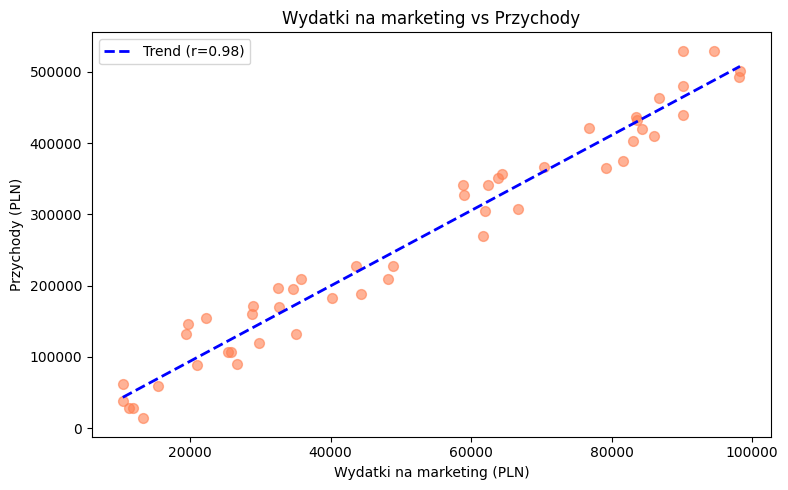

Marketing spend vs Revenue: r = 0.9806, p = 1.22e-35


In [16]:
np.random.seed(100)
n_mkt = 50
marketing_spend = np.random.uniform(10000, 100000, n_mkt)
revenue = marketing_spend * 5.2 + np.random.normal(0, 30000, n_mkt)
revenue = revenue.clip(0)
# Oblicz korelację Pearsona
r_mkt, p_mkt = stats.pearsonr(marketing_spend, revenue)
# Scatter plot z linią trendu
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(marketing_spend, revenue, alpha=0.6, color='coral', s=50)
# Dodaj linię trendu (polyfit stopień 1)
z = np.polyfit(marketing_spend, revenue, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(marketing_spend.min(), marketing_spend.max(), 100)
ax.plot(x_line, p_fit(x_line), 'b--', lw=2, label=f'Trend (r={r_mkt:.2f})')
ax.set_title('Wydatki na marketing vs Przychody')
ax.set_xlabel('Wydatki na marketing (PLN)')
ax.set_ylabel('Przychody (PLN)')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()
print(f"Marketing spend vs Revenue: r = {r_mkt:.4f}, p = {p_mkt:.2e}")

## Ćwiczenie 3: Pełna analiza statystyczna datasetu HR (30 min) — z mniejszym wsparciem

#### 3a. scipy.stats.describe — szybki przegląd rozkładu

In [19]:
from scipy import stats

# Wykonanie opisu statystycznego
desc = stats.describe(df['wynagrodzenie'])

print("=== STATYSTYKI OPISOWE (stats.describe) ===")
print(f"Liczba obserwacji (nobs): {desc.nobs}")
print(f"Minimum:                  {desc.minmax[0]:>10,.2f} PLN")
print(f"Maximum:                  {desc.minmax[1]:>10,.2f} PLN")
print(f"Średnia (mean):           {desc.mean:>10,.2f} PLN")
print(f"Wariancja (variance):     {desc.variance:>10,.2f}")
print(f"Skośność (skewness):      {desc.skewness:>10.4f}")
print(f"Kurtoza (kurtosis):       {desc.kurtosis:>10.4f}")

print("\n=== INTERPRETACJA SŁOWNA ===")
# Interpretacja skośności
if desc.skewness > 0:
    print("Skośność > 0: Rozkład jest prawostronnie asymetryczny (prawoskośny).")
    print("""              Oznacza to, że większość pracowników zarabia poniżej średniej,
              a "ogon" rozkładu ciągnie się w stronę bardzo wysokich pensji.""")
elif desc.skewness < 0:
    print("Skośność < 0: Rozkład jest lewostronnie asymetryczny (lewoskośny).")
    print("              Większość osób zarabia powyżej średniej.")
else:
    print("Skośność = 0: Rozkład jest idealnie symetryczny.")

print("-" * 50)

# Interpretacja kurtozy (scipy domyślnie zwraca tzw. kurtozę przebitkową / excess kurtosis)
if desc.kurtosis > 0:
    print("Kurtoza > 0:  Rozkład jest leptokurtyczny (wysmukły).")
    print("              Wartości są silnie skoncentrowane wokół średniej, ale jednocześnie")
    print("              występuje zwiększone prawdopodobieństwo pojawienia się wartości")
    print("              skrajnych (tzw. grube ogony – np. pojedyncze gigantyczne pensje).")
elif desc.kurtosis < 0:
    print("Kurtoza < 0:  Rozkład jest platokurtyczny (spłaszczony).")
    print("              Wartości są bardziej „rozlane” i rówomiernie rozłożone,")
    print("              a wokół średniej jest mniejsze zagęszczenie.")
else:
    print("Kurtoza = 0:  Rozkład jest mezokurtyczny (normalny pod względem koncentracji).")

=== STATYSTYKI OPISOWE (stats.describe) ===
Liczba obserwacji (nobs): 200
Minimum:                    2,000.00 PLN
Maximum:                   40,000.00 PLN
Średnia (mean):             9,940.00 PLN
Wariancja (variance):     15,838,190.95
Skośność (skewness):          5.1024
Kurtoza (kurtosis):          34.1594

=== INTERPRETACJA SŁOWNA ===
Skośność > 0: Rozkład jest prawostronnie asymetryczny (prawoskośny).
              Oznacza to, że większość pracowników zarabia poniżej średniej,
              a "ogon" rozkładu ciągnie się w stronę bardzo wysokich pensji.
--------------------------------------------------
Kurtoza > 0:  Rozkład jest leptokurtyczny (wysmukły).
              Wartości są silnie skoncentrowane wokół średniej, ale jednocześnie
              występuje zwiększone prawdopodobieństwo pojawienia się wartości
              skrajnych (tzw. grube ogony – np. pojedyncze gigantyczne pensje).


#### 3b. Analiza percentylowa

In [21]:
percentyle_lista = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
wyniki_percentyli = df['wynagrodzenie'].quantile(percentyle_lista)

print("=== ROZKŁAD PERCENTYLOWY WYNAGRODZEŃ ===")
print(f"{'Percentyl':<10} | {'Wartość (PLN)':<15}")
print("-" * 30)

for q, wartosc in wyniki_percentyli.items():
    p_nazwa = f"P{int(q * 100)}"
    print(f"{p_nazwa:<10} | {wartosc:>12,.0f} PLN")

=== ROZKŁAD PERCENTYLOWY WYNAGRODZEŃ ===
Percentyl  | Wartość (PLN)  
------------------------------
P10        |        7,190 PLN
P25        |        8,200 PLN
P50        |        9,450 PLN
P75        |       10,700 PLN
P90        |       12,310 PLN
P95        |       13,105 PLN
P99        |       35,030 PLN


#### 3c. Analiza per dział — pełna tabela

In [22]:
import pandas as pd

# 1. Agregacja danych per dział
statystyki_dzial = df.groupby('dzial', observed=True)['wynagrodzenie'].agg(
    Średnia='mean',
    Mediana='median',
    Std='std',
    Min='min',
    Max='max',
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

# 2. Sortowanie malejąco po medianie
statystyki_dzial = statystyki_dzial.sort_values(by='Mediana', ascending=False)

# 3. Wyświetlenie sformatowanej tabeli
print("=== STATYSTYKI WYNAGRODZEŃ PER DZIAŁ ===")
# Stosujemy formatowanie walutowe dla wszystkich kolumn w tabeli
pd.options.display.float_format = '{:,.0f} PLN'.format
print(statystyki_dzial)

# Przywrócenie domyślnego formatowania pandas (opcjonalnie)
pd.reset_option('display.float_format')

=== STATYSTYKI WYNAGRODZEŃ PER DZIAŁ ===
             Średnia    Mediana       Std       Min        Max       IQR
dzial                                                                   
IT        11,108 PLN 10,600 PLN 4,145 PLN 2,500 PLN 40,000 PLN 2,750 PLN
Finanse   10,621 PLN 10,400 PLN 1,741 PLN 8,300 PLN 16,200 PLN 2,000 PLN
Marketing  9,476 PLN  9,100 PLN 4,386 PLN 2,000 PLN 35,000 PLN 1,500 PLN
HR         8,354 PLN  8,400 PLN 1,622 PLN 4,500 PLN 10,800 PLN 2,425 PLN
Sprzedaz   9,282 PLN  8,400 PLN 4,428 PLN 5,900 PLN 38,000 PLN 2,075 PLN


#### 3d. Wizualizacja — boxplot per dział

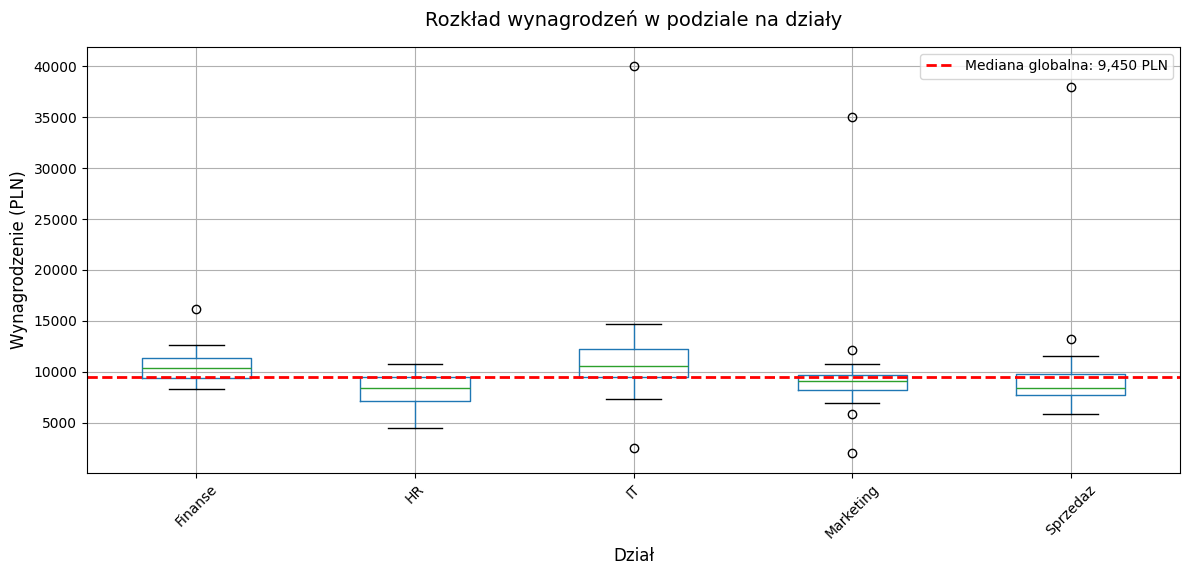

In [23]:
import matplotlib.pyplot as plt

# 1. Tworzenie wykresu pudełkowego za pomocą Pandas
# Metoda df.boxplot() zwraca obiekt osi (Axes) - przechwytujemy go do zmiennej 'ax'
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='wynagrodzenie', by='dzial', ax=ax, grid=True)

# 2. Obliczenie i dodanie poziomej linii mediany globalnej
mediana_globalna = df['wynagrodzenie'].median()
ax.axhline(mediana_globalna, color='red', linestyle='--', lw=2, label=f'Mediana globalna: {mediana_globalna:,.0f} PLN')

# 3. Dostosowanie tytułów i etykiet (czyszczenie domyślnego nagłówka pandas)
plt.suptitle('')  # Usuwa automatyczny, dodatkowy tytuł "Boxplot grouped by dzial"
ax.set_title('Rozkład wynagrodzeń w podziale na działy', fontsize=14, pad=15)
ax.set_xlabel('Dział', fontsize=12)
ax.set_ylabel('Wynagrodzenie (PLN)', fontsize=12)

# 4. Obrócenie etykiet działów (przydatne przy długich nazwach) oraz dodanie legendy
plt.xticks(rotation=45)
ax.legend(loc='upper right')

# 5. Wyświetlenie wykresu
plt.tight_layout()
plt.show()
plt.close()

#### 3e. scipy.stats.describe — per dział IT i HR

In [26]:
from scipy import stats

for d in ['IT', 'HR']:
    podzb = df[df['dzial'].str.lower() == d.lower()]['wynagrodzenie']
    
    if len(podzb) < 3:
        print(f"\nDział {d} ma zbyt mało danych do pełnej analizy opisowej.")
        continue
        
    opis = stats.describe(podzb)
    print(f"\n{d} (n={opis.nobs}):")
    print(f" Skośność: {opis.skewness:.3f}")
    print(f" Kurtoza: {opis.kurtosis:.3f}")

# ==========================================
# INTERPRETACJA WYNIKÓW (Zarobki IT vs HR):
# ==========================================
# 
# 1. SKOŚNOŚĆ (Skewness):
#    - Jeśli Skośność > 0 (np. w IT): Rozkład jest prawoskośny. Oznacza to obecność 
#      "top-earners" (np. managerów/architektów), którzy zarabiają wielokrotność bazy.
#    - Jeśli Skośność bliska 0 (np. w HR): Rozkład jest bardziej symetryczny. Zarobki 
#      są rozłożone równomiernie wokół średniej, brak tam ekstremalnych "kominów płacowych".
#
# 2. KURTOZA (Excess Kurtosis):
#    - Jeśli Kurtoza > 0 (Rozkład leptokurtyczny): Zarobki są mocno skoncentrowane 
#      wokół jednej, typowej dla tego działu stawki (wysoki, ostry pik na wykresie), 
#      ale z "grubymi ogonami" (pojedyncze anomalie).
#    - Jeśli Kurtoza < 0 (Rozkład platokurtyczny): Zarobki w dziale są bardziej 
#      "rozlane" i spłaszczone, co oznacza większą, równomierną rozpiętość stawek 
#      między pracownikami bez wyraźnego dominującego progu.


IT (n=66):
 Skośność: 5.067
 Kurtoza: 34.256

HR (n=24):
 Skośność: -0.460
 Kurtoza: -0.404


## Ćwiczenie 4: Wykrywanie outlierów + commit (15 min)

#### 4a. Wykrywanie outlierów metodą IQR

In [27]:
# Oblicz granice IQR
q1 = df['wynagrodzenie'].quantile(0.25)
q3 = df['wynagrodzenie'].quantile(0.75)
iqr = q3 - q1
dolna = q1 - 1.5 * iqr
gorna = q3 + 1.5 * iqr
print(f"IQR granice: [{dolna:,.0f} PLN, {gorna:,.0f} PLN]")
# Wykryj outlierów
maska_iqr = (df['wynagrodzenie'] < dolna) | (df['wynagrodzenie'] > gorna)
outliery = df[maska_iqr]
print(f"Liczba outlierów: {maska_iqr.sum()} z {len(df)}")
print("\nSzczegóły outlierów:")
print(outliery[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())

IQR granice: [4,450 PLN, 14,450 PLN]
Liczba outlierów: 7 z 200

Szczegóły outlierów:
         dzial  staz_lat  wynagrodzenie
51   Marketing       3.1         2000.0
61          IT      10.6        14700.0
79          IT       6.3        40000.0
83          IT       8.8         2500.0
138   Sprzedaz      13.8        38000.0
154    Finanse      15.3        16200.0
183  Marketing       3.7        35000.0


#### 4b. Wykrywanie outlierów metodą z-score

In [28]:
# Oblicz z-score: stats.zscore()
z_scores = np.abs(stats.zscore(df['wynagrodzenie']))
maska_z = z_scores > 3.0
outliery_z = df[maska_z]
print(f"Outlierzy z-score (|z| > 3.0): {maska_z.sum()} obserwacji")
print(outliery_z[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())

Outlierzy z-score (|z| > 3.0): 3 obserwacji
         dzial  staz_lat  wynagrodzenie
79          IT       6.3        40000.0
138   Sprzedaz      13.8        38000.0
183  Marketing       3.7        35000.0


#### 4c. Wpływ outlierów na statystyki

In [32]:
bez_outlierow = df[~maska_iqr]['wynagrodzenie']
z_outlierami = df['wynagrodzenie']
print(f"{'Miara':<20} {'Z outlierami':>15} {'Bez outlierów':>15} {'Zmiana':>10}")
print("-" * 62)
for nazwa, f_z, f_bez in [
('Średnia', z_outlierami.mean(), bez_outlierow.mean()),
('Mediana', z_outlierami.median(), bez_outlierow.median()),
('Std', z_outlierami.std(), bez_outlierow.std()),
]:
    zmiana = f_z - f_bez
print(f"{nazwa:<20} {f_z:>15,.0f} {f_bez:>15,.0f} {zmiana:>+10,.0f}")

# Odpowiedz w komentarzu: która miara jest bardziej stabilna? Dlaczego?
# Zdecydowanie najbardziej stabilną miarą jest MEDIANA (kolumna 'Zmiana' pokaże przy niej najniższą wartość, bliską 0).
# Wynika to z faktu, że mediana bazuje na pozycji środkowej (pozycyjnej) uszeregowanych danych. 
# Usunięcie skrajnych pensji nie przesuwa środka zbioru, podczas gdy Średnia i Odchylenie Standardowe (Std) 
# są miarami klasycznymi – zależą bezpośrednio od wartości każdego punktu danych, przez co 
# pojedyncze anomalie finansowe potrafią drastycznie zafałszować ich wyniki.

Miara                   Z outlierami   Bez outlierów     Zmiana
--------------------------------------------------------------
Std                            3,980           1,798     +2,182
